In [1]:
#inspecting the input directory as compitition datasets may contain verity ofdifferent files
#which may be are not helpfull or usable.

import os

INPUT_DIR = "/kaggle/input"

for dataset_name in sorted(os.listdir(INPUT_DIR)):
    dataset_path = os.path.join(INPUT_DIR, dataset_name)
    print(f"\n📁 {dataset_name}")
    print("-" * 70)
    for root, dirs, files in os.walk(dataset_path):
        depth = root.replace(dataset_path, "").count(os.sep)
        indent = "   " * depth
        if depth > 0:
            print(f"{indent}📂 {os.path.basename(root)}/")
        for file in sorted(files):
            size_mb = os.path.getsize(os.path.join(root, file)) / (1024 * 1024)
            print(f"{indent}   📄 {file}  ({size_mb:.2f} MB)")


📁 competitions
----------------------------------------------------------------------
   📂 learning-agency-lab-automated-essay-scoring-2/
      📄 sample_submission.csv  (0.00 MB)
      📄 test.csv  (0.01 MB)
      📄 train.csv  (34.51 MB)
   📂 feedback-prize-english-language-learning/
      📄 sample_submission.csv  (0.00 MB)
      📄 test.csv  (0.01 MB)
      📄 train.csv  (8.86 MB)
   📂 asap-aes/
      📄 Essay_Set_Descriptions.zip  (0.21 MB)
      📄 Training_Materials.zip  (54.96 MB)
      📄 test_set.tsv  (5.02 MB)
      📄 training_set_rel3.tsv  (15.58 MB)
      📄 training_set_rel3.xls  (19.03 MB)
      📄 training_set_rel3.xlsx  (6.39 MB)
      📄 valid_sample_submission_1_column.csv  (0.01 MB)
      📄 valid_sample_submission_1_column_no_header.csv  (0.01 MB)
      📄 valid_sample_submission_2_column.csv  (0.04 MB)
      📄 valid_sample_submission_5_column.csv  (0.09 MB)
      📄 valid_set.tsv  (5.05 MB)
      📄 valid_set.xls  (6.12 MB)
      📄 valid_set.xlsx  (2.06 MB)


In [2]:
import pandas as pd

BASE = "/kaggle/input/competitions"

aes_path  = f"{BASE}/learning-agency-lab-automated-essay-scoring-2/train.csv"
ell_path  = f"{BASE}/feedback-prize-english-language-learning/train.csv"
asap_path = f"{BASE}/asap-aes/training_set_rel3.tsv"

aes  = pd.read_csv(aes_path)
ell  = pd.read_csv(ell_path)
asap = pd.read_csv(asap_path, sep="\t", encoding="latin-1")

datasets = {"AES 2.0": aes, "ELL": ell, "ASAP": asap}

for name, df in datasets.items():
    print(f"\n{'=' * 70}")
    print(f"{name}  |  {df.shape[0]:,} rows x {df.shape[1]} columns")
    print("=" * 70)
    print("\nColumns and data types:")
    print(df.dtypes.to_string())
    print("\nMissing values per column (only columns with any):")
    missing = df.isna().sum()
    print(missing[missing > 0].to_string() if missing.sum() > 0 else "None")


AES 2.0  |  17,307 rows x 3 columns

Columns and data types:
essay_id     object
full_text    object
score         int64

Missing values per column (only columns with any):
None

ELL  |  3,911 rows x 8 columns

Columns and data types:
text_id         object
full_text       object
cohesion       float64
syntax         float64
vocabulary     float64
phraseology    float64
grammar        float64
conventions    float64

Missing values per column (only columns with any):
None

ASAP  |  12,976 rows x 28 columns

Columns and data types:
essay_id            int64
essay_set           int64
essay              object
rater1_domain1      int64
rater2_domain1      int64
rater3_domain1    float64
domain1_score       int64
rater1_domain2    float64
rater2_domain2    float64
domain2_score     float64
rater1_trait1     float64
rater1_trait2     float64
rater1_trait3     float64
rater1_trait4     float64
rater1_trait5     float64
rater1_trait6     float64
rater2_trait1     float64
rater2_trait2     flo

In [3]:
import textwrap

def show_samples(df, text_col, info_cols, n=2, chars=700, seed=42):
    sample = df.sample(n, random_state=seed)
    for _, row in sample.iterrows():
        print("-" * 70)
        for col in info_cols:
            print(f"{col}: {row[col]}")
        print("TEXT:")
        print(textwrap.fill(row[text_col][:chars], width=100), "...")

# ---------- AES 2.0 ----------
print("=" * 70)
print("AES 2.0 | sample essays")
show_samples(aes, "full_text", ["essay_id", "score"])

aes_dist = pd.DataFrame({
    "count": aes["score"].value_counts().sort_index(),
    "percent": (aes["score"].value_counts(normalize=True).sort_index() * 100).round(1),
})
print("\nAES 2.0 | score distribution")
print(aes_dist.to_string())

# ---------- ELL ----------
trait_cols = ["cohesion", "syntax", "vocabulary", "phraseology", "grammar", "conventions"]

print("\n" + "=" * 70)
print("ELL | sample essays")
show_samples(ell, "full_text", ["text_id"] + trait_cols)

print("\nELL | trait score summary")
print(ell[trait_cols].describe().round(2).to_string())

# ---------- ASAP ----------
print("\n" + "=" * 70)
print("ASAP | sample essays")
show_samples(asap, "essay", ["essay_id", "essay_set", "domain1_score"])

print("\nASAP | domain1_score by essay set")
print(asap.groupby("essay_set")["domain1_score"]
          .agg(["count", "min", "max", "mean"]).round(2).to_string())

AES 2.0 | sample essays
----------------------------------------------------------------------
essay_id: bb4c434
score: 3
TEXT:
People tend to use there cars so much, they basically can't live or get through the day with out
their car. We use the car to go every where rather it's to the grocery store , work or just to go
hang out with friends and family! Just traveling in general. Well imagine if we limited the usage of
cars in our community! I strongly believe that doing this would have many advantages to our
community for many reasons like it will make people less stressful all the time, there would be less
accidents and it would definitly be better for the environment.  OMG I ran out of gas or OH my i
have to take my car to the shop to get it fixed is usually the two main things you hear people stay
when the word ...
----------------------------------------------------------------------
essay_id: 44e88b0
score: 3
TEXT:
Imagine being a top scientist at NASA and Viking 1 spacecraft "s

In [4]:
import numpy as np

def text_report(df, text_col, name):
    words = df[text_col].str.split().str.len()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Word count summary:")
    print(words.describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_string())
    print(f"\nVery short essays (under 50 words): {(words < 50).sum()}")
    print(f"Exact duplicate essays: {df[text_col].duplicated().sum()}")
    has_para = df[text_col].str.contains("\n\n", regex=False).mean() * 100
    print(f"Essays containing a blank-line paragraph break: {has_para:.1f}%")
    return words

aes_words  = text_report(aes,  "full_text", "AES 2.0")
ell_words  = text_report(ell,  "full_text", "ELL")
asap_words = text_report(asap, "essay",     "ASAP")

print("\n" + "=" * 70)
print("How strongly does length track the score? (Spearman correlation)")
print("=" * 70)

print("\nAES 2.0 (word count vs score):",
      round(aes_words.corr(aes["score"], method="spearman"), 3))

print("\nELL (word count vs each trait):")
print(ell[trait_cols].corrwith(ell_words, method="spearman").round(3).to_string())

print("\nASAP (word count vs score, per essay set):")
asap_tmp = asap.assign(words=asap_words)
print(asap_tmp.groupby("essay_set")[["words", "domain1_score"]]
              .apply(lambda g: g["words"].corr(g["domain1_score"], method="spearman"))
              .round(3).to_string())

AES 2.0
Word count summary:
count    17307.0
mean       368.3
std        150.4
min        150.0
50%        345.0
75%        452.0
90%        564.0
95%        650.0
99%        823.9
max       1656.0

Very short essays (under 50 words): 0
Exact duplicate essays: 0
Essays containing a blank-line paragraph break: 94.6%
ELL
Word count summary:
count    3911.0
mean      430.5
std       191.9
min        14.0
50%       402.0
75%       526.5
90%       672.0
95%       788.0
99%      1099.9
max      1260.0

Very short essays (under 50 words): 2
Exact duplicate essays: 0
Essays containing a blank-line paragraph break: 93.8%
ASAP
Word count summary:
count    12976.0
mean       222.7
std        175.9
min          2.0
50%        163.0
75%        307.0
90%        472.5
95%        588.0
99%        840.2
max       1064.0

Very short essays (under 50 words): 912
Exact duplicate essays: 4
Essays containing a blank-line paragraph break: 0.0%

How strongly does length track the score? (Spearman correlation)

In [5]:
import zipfile, io, re
from collections import Counter

# ---------- 1. ASAP essay set descriptions (read directly from the zip) ----------
zip_path = f"{BASE}/asap-aes/Essay_Set_Descriptions.zip"

with zipfile.ZipFile(zip_path) as z:
    names = z.namelist()
    print("Files inside Essay_Set_Descriptions.zip:")
    for n in names:
        print("  ", n)

    for n in names:
        if n.lower().endswith(".docx"):
            with zipfile.ZipFile(io.BytesIO(z.read(n))) as docx_file:
                xml = docx_file.read("word/document.xml").decode("utf-8")
            xml = xml.replace("</w:p>", "\n")
            text = re.sub(r"<[^>]+>", "", xml)
            text = re.sub(r"\n\s*\n+", "\n", text).strip()
            print("\n" + "=" * 70)
            print(n)
            print("=" * 70)
            print(text[:500])

# ---------- 2. Anonymization tokens ----------
print("\n" + "=" * 70)
print("ASAP | anonymization tokens (like @PERSON1, @NUM1)")
print("=" * 70)

pattern = r"@[A-Za-z]+\d*"
all_tokens = [t for essay in asap["essay"] for t in re.findall(pattern, essay)]
token_types = Counter(re.sub(r"\d+", "", t) for t in all_tokens)

has_token = asap["essay"].str.contains(pattern, regex=True)
print(f"Essays containing at least one token: {has_token.sum():,} ({has_token.mean() * 100:.1f}%)")
print(f"Total tokens found: {len(all_tokens):,}")
print("\nToken types (numbers removed), most common first:")
for token, count in token_types.most_common(15):
    print(f"  {token:<15} {count:,}")

print("\nEssays containing '@' in AES 2.0:", aes["full_text"].str.contains("@", regex=False).sum())
print("Essays containing '@' in ELL:    ", ell["full_text"].str.contains("@", regex=False).sum())

# ---------- 3. The 2 very short ELL essays ----------
print("\n" + "=" * 70)
print("ELL | essays under 50 words")
print("=" * 70)
short_ell = ell[ell["full_text"].str.split().str.len() < 50]
for _, row in short_ell.iterrows():
    print(f"\n{row['text_id']}")
    print(row[trait_cols].to_dict())
    print("TEXT:", row["full_text"])

# ---------- 4. The 4 exact duplicates in ASAP ----------
print("\n" + "=" * 70)
print("ASAP | rows involved in exact duplicates")
print("=" * 70)
dups = asap[asap["essay"].duplicated(keep=False)].sort_values("essay")
view = dups[["essay_id", "essay_set", "domain1_score"]].copy()
view["preview"] = dups["essay"].str[:80]
print(view.to_string())

Files inside Essay_Set_Descriptions.zip:
   Essay_Set_Descriptions/Essay Set #1--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #2--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #3--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #4--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #5--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #6--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #7--ReadMeFirst.docx
   Essay_Set_Descriptions/Essay Set #8--ReadMeFirst.docx
   Essay_Set_Descriptions/essay_set_descriptions.xlsx
   Essay_Set_Descriptions/Guidelines for Transcribing Student Essays.docx

Essay_Set_Descriptions/Essay Set #1--ReadMeFirst.docx
Essay Set #1
Type of essay:
Persuasive/ Narrative/Expository
Grade level:
8
Training set size:
1,785 essays
Final evaluation set size:
592 essays
Average length of essays:
350 words
Scoring:
Score1, Score2, Resolved Score
Rubric range:
1-6
Resolved score range:
2-12
Prompt
More and more people use computers, but not ev

## Exploratory Data Analysis

Before building any model, we look at the data visually. From here on, every chart uses one shared dark theme and colour palette so the notebook reads as a single story.

**Chart 1: Score distribution (AES 2.0).** How many essays received each score from 1 to 6? This shows whether the data is balanced, which directly affects how we split the data and how we judge the model.

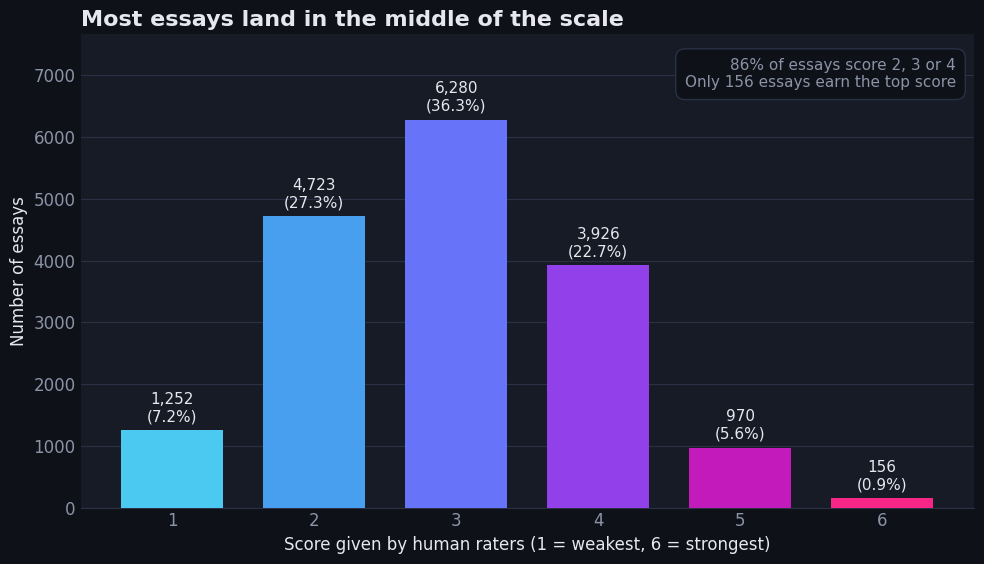

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---------- Shared theme (reused by every chart in this notebook) ----------
BG, PANEL   = "#0E1117", "#161B26"
TEXT, MUTED = "#E6E8EE", "#8B93A7"
GRID        = "#2A3145"

PALETTE = ["#4CC9F0", "#4895EF", "#7B5CFF", "#B517C9", "#F72585"]
cmap = LinearSegmentedColormap.from_list("essay_gradient", PALETTE)

mpl.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "savefig.facecolor": BG,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 12,
    "text.color": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "font.size": 12,
})

# ---------- Chart 1: AES 2.0 score distribution ----------
counts = aes["score"].value_counts().sort_index()
pct = counts / counts.sum() * 100
bar_colors = [cmap(i / (len(counts) - 1)) for i in range(len(counts))]

fig, ax = plt.subplots(figsize=(10, 5.8))
bars = ax.bar(counts.index, counts.values, color=bar_colors, width=0.72, zorder=3)

for score, bar in zip(counts.index, bars):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.015,
        f"{counts[score]:,}\n({pct[score]:.1f}%)",
        ha="center", va="bottom", color=TEXT, fontsize=11,
    )

middle_share = pct.loc[2:4].sum()
ax.text(
    0.98, 0.95,
    f"{middle_share:.0f}% of essays score 2, 3 or 4\nOnly {counts[6]} essays earn the top score",
    transform=ax.transAxes, ha="right", va="top", fontsize=11, color=MUTED,
    bbox=dict(boxstyle="round,pad=0.6", facecolor=BG, edgecolor=GRID),
)

ax.set_title("Most essays land in the middle of the scale")
ax.set_xlabel("Score given by human raters (1 = weakest, 6 = strongest)")
ax.set_ylabel("Number of essays")
ax.set_xticks(counts.index)
ax.set_ylim(0, counts.max() * 1.22)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="both", length=0)

plt.tight_layout()
fig.savefig("/kaggle/working/chart1_aes_score_distribution.png", dpi=200)
plt.show()

##  Data Cleaning (ASAP)

The raw ASAP data has four issues, and each one is fixed here in a documented way:

1. **Duplicate essays**: 4 exact duplicates are removed (the first copy is kept).
2. **Different score scales**: each prompt uses its own scale (for example 0-3 for set 3, 0-60 for set 8). Scores are rescaled to 0-1 using the **official** ranges from the competition's set descriptions, so they can be compared across prompts.
3. **Two kinds of task**: sets 1, 2, 7, 8 are true essays; sets 3-6 are short answers about a reading passage. They are labelled separately and will be evaluated separately.
4. **Anonymisation placeholders**: tokens like `@PERSON1` or `@NUM2` are replaced with natural stand-in words so that spelling and grammar tools do not treat them as errors.

The essay text is otherwise kept **raw**: no lowercasing, no spelling correction and no punctuation removal, because those errors are part of what the scores measure.

In [7]:
import re
import numpy as np

# ---------- Official score ranges (from Essay_Set_Descriptions.zip) ----------
SET_RANGES = {
    1: (2, 12), 2: (1, 6), 3: (0, 3), 4: (0, 3),
    5: (0, 4),  6: (0, 4), 7: (0, 30), 8: (0, 60),
}

# ---------- Stand-in words for the anonymisation tokens ----------
TOKEN_REPLACEMENTS = {
    "CAPS": "Example", "NUM": "5", "PERSON": "Alex", "LOCATION": "Denver",
    "ORGANIZATION": "Company", "MONTH": "March", "DATE": "May 5",
    "PERCENT": "50%", "TIME": "5:00", "MONEY": "$5", "DR": "Smith",
    "STATE": "Ohio", "CITY": "Boston", "EMAIL": "Sam",
}
token_pattern = re.compile(r"@([A-Za-z]+)\d*")

def replace_token(match):
    return TOKEN_REPLACEMENTS.get(match.group(1).upper(), "Something")

# ---------- Build the cleaned table (raw `asap` stays untouched) ----------
asap_clean = asap.copy()
rows_before = len(asap_clean)

# 1. Drop duplicate essays (keep the first copy)
asap_clean = asap_clean.drop_duplicates(subset="essay", keep="first").reset_index(drop=True)

# 2. Rescale scores to 0-1 using the official ranges
low  = asap_clean["essay_set"].map(lambda s: SET_RANGES[s][0])
high = asap_clean["essay_set"].map(lambda s: SET_RANGES[s][1])
asap_clean["score_scaled"] = (asap_clean["domain1_score"] - low) / (high - low)

# 3. Label the two task types
asap_clean["task_type"] = np.where(
    asap_clean["essay_set"].isin([1, 2, 7, 8]), "essay", "short_answer"
)

# 4. Replace the placeholder tokens (original text is kept in `essay`)
asap_clean["essay_clean"] = asap_clean["essay"].apply(lambda t: token_pattern.sub(replace_token, t))

# ---------- Checks ----------
print(f"Rows: {rows_before:,} -> {len(asap_clean):,}  (dropped {rows_before - len(asap_clean)})")

print("\nScaled score check, per essay set:")
check = asap_clean.groupby("essay_set").agg(
    essays=("essay_id", "count"),
    task=("task_type", "first"),
    scaled_min=("score_scaled", "min"),
    scaled_max=("score_scaled", "max"),
    scaled_mean=("score_scaled", "mean"),
).round(3)
print(check.to_string())

print("\nEssays per task type:")
print(asap_clean["task_type"].value_counts().to_string())

print("\nTokens remaining after replacement:",
      asap_clean["essay_clean"].str.contains("@", regex=False).sum())

example = asap_clean[asap_clean["essay"].str.contains("@", regex=False)].iloc[0]
print("\nBEFORE:", example["essay"][:750])
print("\nAFTER: ", example["essay_clean"][:750])

Rows: 12,976 -> 12,972  (dropped 4)

Scaled score check, per essay set:
           essays          task  scaled_min  scaled_max  scaled_mean
essay_set                                                           
1            1783         essay       0.000         1.0        0.653
2            1800         essay       0.000         1.0        0.483
3            1724  short_answer       0.000         1.0        0.616
4            1768  short_answer       0.000         1.0        0.478
5            1805  short_answer       0.000         1.0        0.602
6            1800  short_answer       0.000         1.0        0.680
7            1569         essay       0.067         0.8        0.535
8             723         essay       0.167         1.0        0.616

Essays per task type:
task_type
short_answer    7097
essay           5875

Tokens remaining after replacement: 3

BEFORE: Dear local newspaper, I think effects computers have on people are great learning skills/affects because they give 

**Chart 2: Essay length vs. score (AES 2.0).** Do higher-scoring essays tend to be longer? Each box shows the middle 50% of essay lengths for one score, and the white line inside is the median. Extreme outliers are hidden so the boxes stay readable. This matters because length is a very strong shortcut: a good model must do better than simply rewarding long essays.

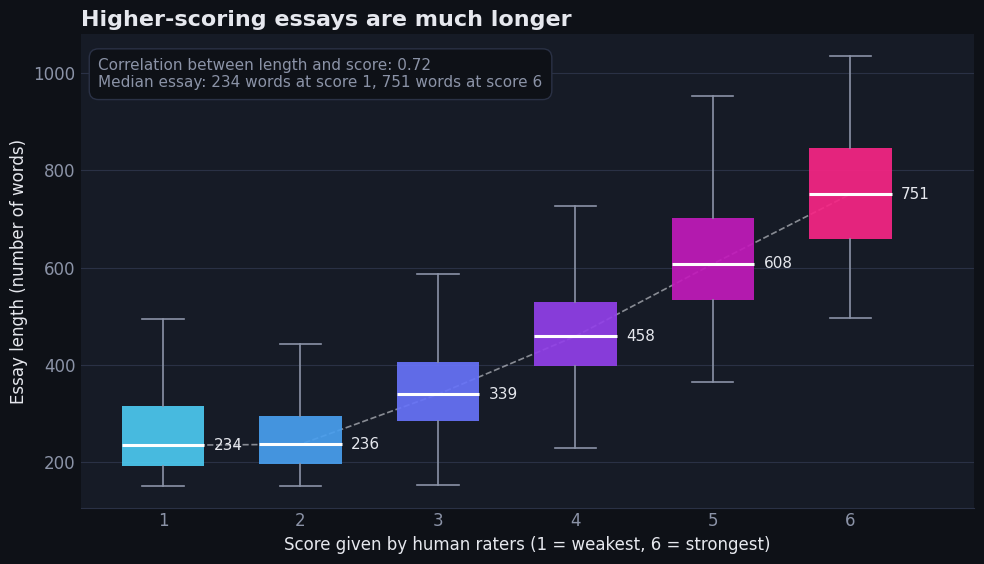

In [8]:
# ---------- Chart 2: essay length vs score (AES 2.0) ----------
aes["word_count"] = aes["full_text"].str.split().str.len()

scores  = sorted(aes["score"].unique())
groups  = [aes.loc[aes["score"] == s, "word_count"] for s in scores]
medians = [g.median() for g in groups]
rho     = aes["word_count"].corr(aes["score"], method="spearman")

fig, ax = plt.subplots(figsize=(10, 5.8))

bp = ax.boxplot(
    groups, positions=scores, widths=0.6, patch_artist=True, showfliers=False,
    medianprops=dict(color="white", linewidth=2.2),
    whiskerprops=dict(color=MUTED, linewidth=1.2),
    capprops=dict(color=MUTED, linewidth=1.2),
    boxprops=dict(linewidth=0),
)

for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(cmap(i / (len(scores) - 1)))
    patch.set_alpha(0.92)

ax.plot(scores, medians, color=TEXT, linestyle="--", linewidth=1.2, alpha=0.55, zorder=1)

for s, m in zip(scores, medians):
    ax.text(s + 0.37, m, f"{m:.0f}", va="center", ha="left", color=TEXT, fontsize=11)

ax.text(
    0.02, 0.95,
    f"Correlation between length and score: {rho:.2f}\n"
    f"Median essay: {medians[0]:.0f} words at score 1, {medians[-1]:.0f} words at score 6",
    transform=ax.transAxes, ha="left", va="top", fontsize=11, color=MUTED,
    bbox=dict(boxstyle="round,pad=0.6", facecolor=BG, edgecolor=GRID),
)

ax.set_title("Higher-scoring essays are much longer")
ax.set_xlabel("Score given by human raters (1 = weakest, 6 = strongest)")
ax.set_ylabel("Essay length (number of words)")
ax.set_xticks(scores)
ax.set_xlim(0.4, 6.9)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="both", length=0)

plt.tight_layout()
fig.savefig("/kaggle/working/chart2_length_vs_score.png", dpi=200)
plt.show()

**Chart 3: How the six writing traits relate (ELL).** Each essay in the ELL dataset is scored on six separate traits:

- **Cohesion**: how well ideas connect and flow
- **Syntax**: sentence structure and variety
- **Vocabulary**: range and accuracy of word choice
- **Phraseology**: natural word combinations and expressions
- **Grammar**: grammatical correctness
- **Conventions**: spelling, punctuation and capitalisation

Each cell shows how closely two traits move together (1 = they always rise and fall together, 0 = unrelated). This tells us whether the traits measure different things or mostly one general "writing ability", which let me decide how to design the trait model later.

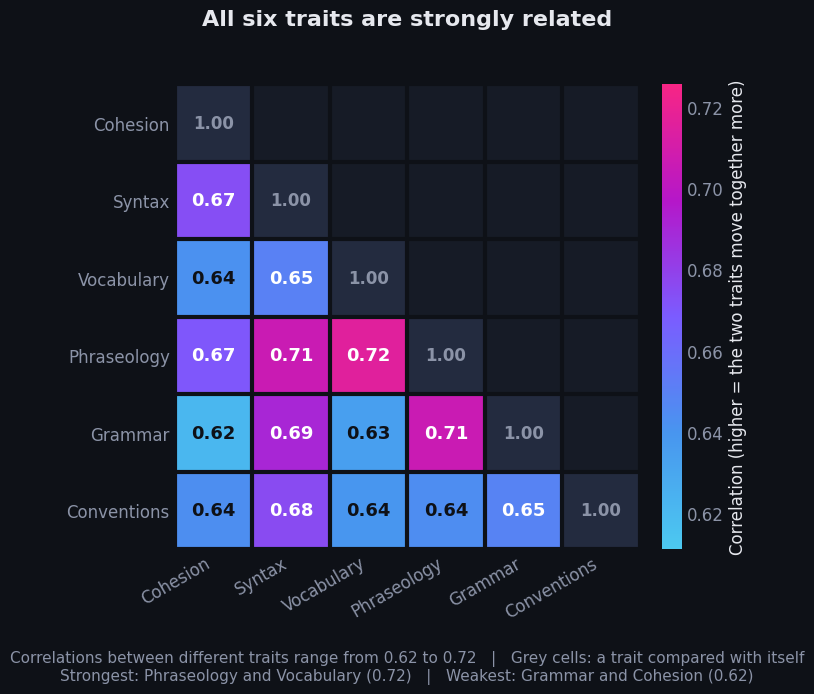

In [9]:
import numpy as np
from matplotlib.patches import Rectangle

# ---------- Chart 3 (v3): correlation between the six ELL traits ----------
trait_labels = ["Cohesion", "Syntax", "Vocabulary", "Phraseology", "Grammar", "Conventions"]
n = len(trait_labels)

values = ell[trait_cols].corr(method="spearman").values

# Strongest and weakest pair (each pair counted once, diagonal excluded)
pairs = [(trait_labels[i], trait_labels[j], values[i, j])
         for i in range(n) for j in range(i)]
strongest = max(pairs, key=lambda p: p[2])
weakest   = min(pairs, key=lambda p: p[2])
lo, hi = weakest[2], strongest[2]

# Data for the gradient: hide the diagonal AND the mirrored upper half
data = values.copy()
data[np.triu_indices_from(data, k=0)] = np.nan
vmin, vmax = lo - 0.01, hi + 0.01

# Manual layout so everything is centred on the figure
fig = plt.figure(figsize=(10, 7.5))
ax  = fig.add_axes([0.2675, 0.22, 0.465, 0.62])
cax = fig.add_axes([0.755, 0.22, 0.02, 0.62])

im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)

for i in range(n):
    # Diagonal cell: a trait compared with itself (neutral grey, always 1.00)
    ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, facecolor="#232B3F", edgecolor="none"))
    ax.text(i, i, "1.00", ha="center", va="center", fontsize=12,
            fontweight="bold", color=MUTED)
    # Real pairs below the diagonal
    for j in range(i):
        v = data[i, j]
        position = (v - vmin) / (vmax - vmin)
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=13,
                fontweight="bold", color=BG if position < 0.3 else "white")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(trait_labels, rotation=30, ha="right")
ax.set_yticklabels(trait_labels)
ax.tick_params(length=0)

# Gaps between cells
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=BG, linewidth=3)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)

cbar = fig.colorbar(im, cax=cax)
cbar.outline.set_visible(False)
cbar.ax.tick_params(colors=MUTED, length=0)
cbar.set_label("Correlation (higher = the two traits move together more)", color=TEXT)

fig.suptitle("All six traits are strongly related", x=0.5, y=0.94,
             fontsize=16, fontweight="bold", color=TEXT, ha="center")
fig.text(
    0.5, 0.04,
    f"Correlations between different traits range from {lo:.2f} to {hi:.2f}   |   "
    f"Grey cells: a trait compared with itself\n"
    f"Strongest: {strongest[0]} and {strongest[1]} ({strongest[2]:.2f})   |   "
    f"Weakest: {weakest[0]} and {weakest[1]} ({weakest[2]:.2f})",
    color=MUTED, fontsize=11, ha="center", va="bottom",
)

fig.savefig("/kaggle/working/chart3_trait_correlations.png", dpi=200)
plt.show()

**Chart 4: ASAP scores after rescaling (one panel per prompt).** ASAP's eight prompts use very different scoring scales (0-3, 1-6, 0-60 and so on). We rescaled every score to a common 0-1 scale using the **official** score ranges, so the panels can be compared side by side. Each bar shows the share of essays at one score, and the dashed line marks the prompt's average.

- **Cyan** panels are full essays (sets 1, 2, 7, 8), which are the fair test of our model.
- **Pink** panels are short answers about a reading passage (sets 3-6), which measure content correctness as much as writing quality, so they are analysed separately.

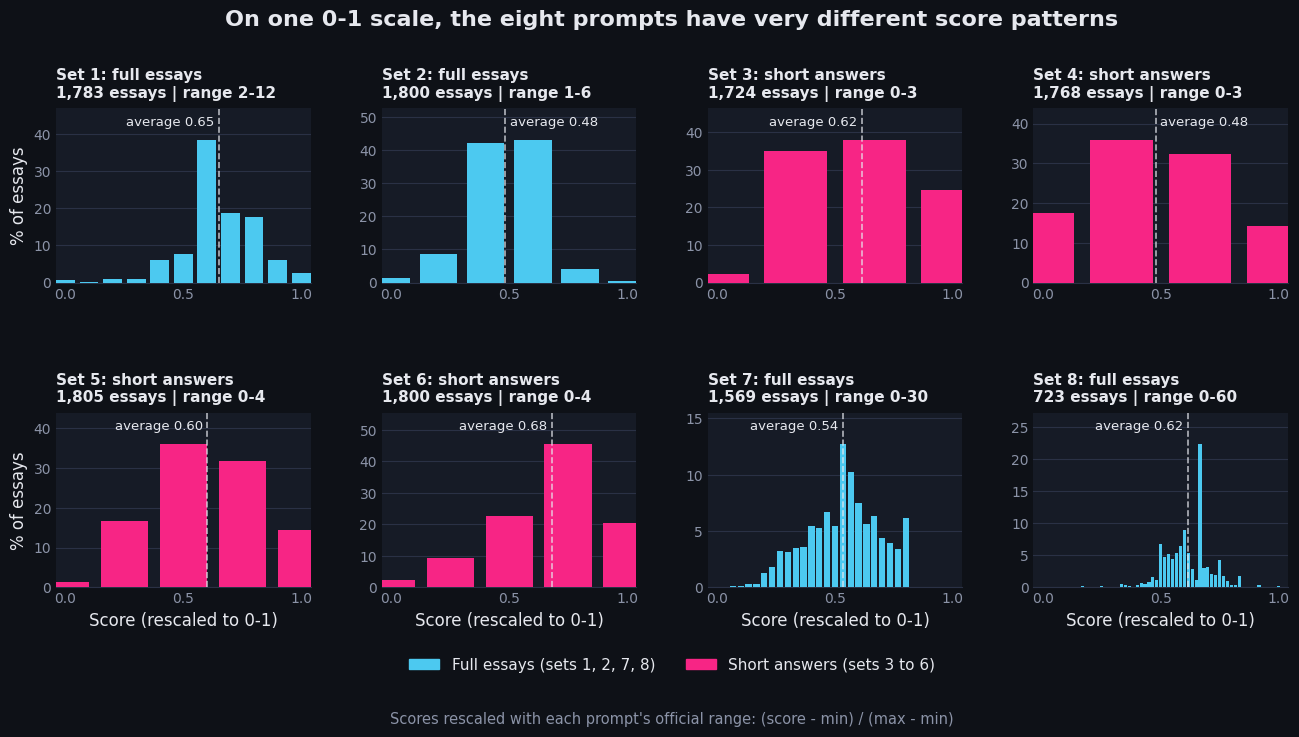

In [10]:
from matplotlib.patches import Patch

# ---------- Chart 4: ASAP rescaled score distributions, one panel per prompt ----------
ESSAY_COLOR, SHORT_COLOR = PALETTE[0], PALETTE[4]
essay_sets = [1, 2, 7, 8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7.6))

for ax, s in zip(axes.flat, range(1, 9)):
    d = asap_clean[asap_clean["essay_set"] == s]
    lo_s, hi_s = SET_RANGES[s]
    is_essay = s in essay_sets
    color = ESSAY_COLOR if is_essay else SHORT_COLOR

    dist = d["score_scaled"].round(6).value_counts(normalize=True).sort_index() * 100
    mean = d["score_scaled"].mean()

    ax.bar(dist.index, dist.values, width=0.8 / (hi_s - lo_s), color=color, zorder=3)
    ax.axvline(mean, color=TEXT, linestyle="--", linewidth=1.2, alpha=0.75, zorder=4)

    top = dist.max() * 1.22
    ax.set_ylim(0, top)
    ax.set_xlim(-0.04, 1.04)
    ax.text(mean + (-0.02 if mean > 0.5 else 0.02), top * 0.96, f"average {mean:.2f}",
            ha="right" if mean > 0.5 else "left", va="top", fontsize=9.5, color=TEXT)

    kind = "full essays" if is_essay else "short answers"
    ax.set_title(f"Set {s}: {kind}\n{len(d):,} essays | range {lo_s}-{hi_s}",
                 fontsize=11, pad=8)

    ax.set_xticks([0, 0.5, 1])
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="both", length=0, labelsize=10)

for ax in axes[:, 0]:
    ax.set_ylabel("% of essays")
for ax in axes[1, :]:
    ax.set_xlabel("Score (rescaled to 0-1)")

fig.subplots_adjust(left=0.06, right=0.94, top=0.83, bottom=0.2, hspace=0.75, wspace=0.28)

fig.suptitle("On one 0-1 scale, the eight prompts have very different score patterns",
             x=0.5, y=0.96, fontsize=16, fontweight="bold", color=TEXT, ha="center")

fig.legend(
    handles=[Patch(color=ESSAY_COLOR, label="Full essays (sets 1, 2, 7, 8)"),
             Patch(color=SHORT_COLOR, label="Short answers (sets 3 to 6)")],
    loc="lower center", bbox_to_anchor=(0.5, 0.07), ncol=2, frameon=False,
    labelcolor=TEXT, fontsize=11,
)
fig.text(0.5, 0.02,
         "Scores rescaled with each prompt's official range: (score - min) / (max - min)",
         ha="center", color=MUTED, fontsize=10.5)

fig.savefig("/kaggle/working/chart4_asap_rescaled_scores.png", dpi=200)
plt.show()

**Chart 5: Essay length across the datasets.** Each panel shows how long the essays are in one dataset (bars = share of essays per 25-word band). The dashed line marks roughly where a standard transformer model (512 tokens, about 390 words) stops reading, so the share of essays to the right of it is the share that would be **cut off** if we fed the text in unchanged. This decides how we handle long essays when we fine-tune the transformer.

                           dataset  essays  median words  90th percentile  % over 394 words
    AES 2.0 (argumentative essays)   17307           345              564              37.3
      ELL (English-learner essays)    3911           402              672              52.0
ASAP full essays (sets 1, 2, 7, 8)    5875           329              602              35.9
  ASAP short answers (sets 3 to 6)    7097           116              197               0.1


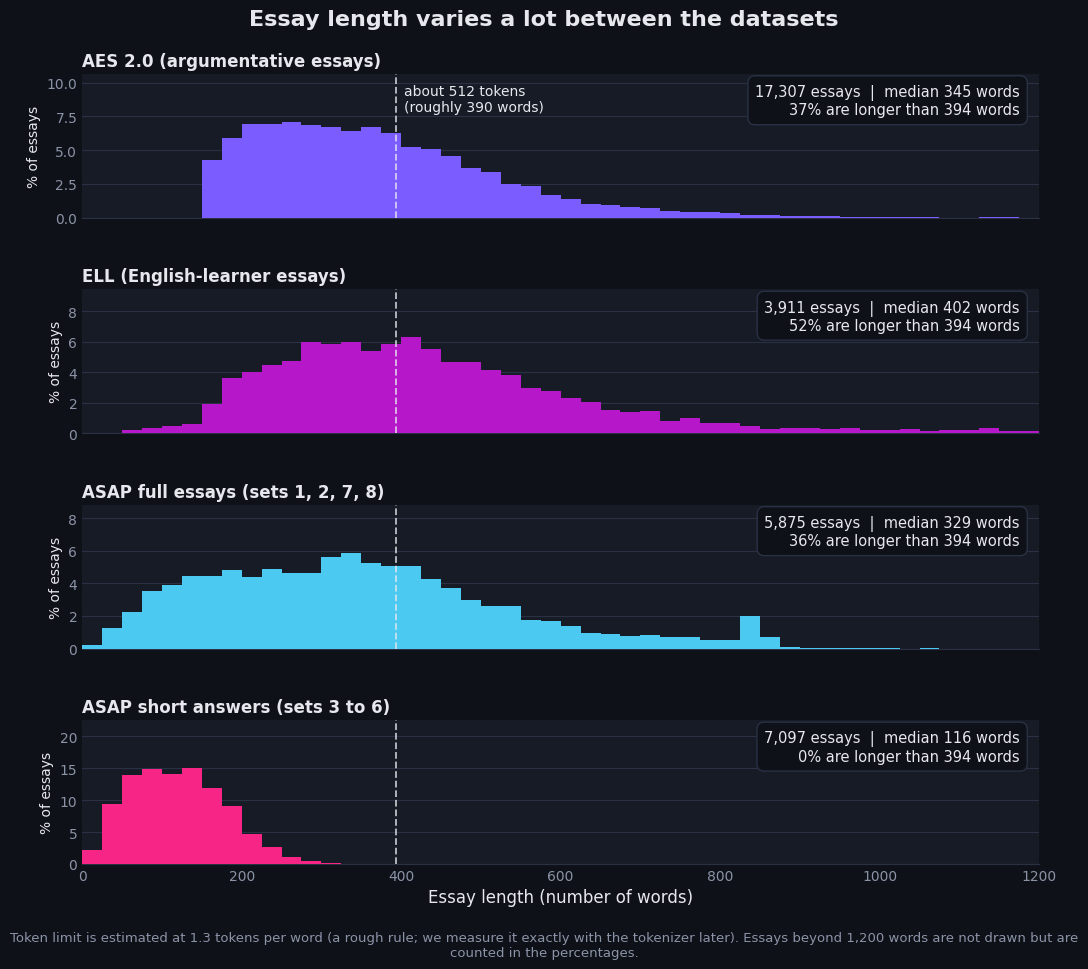

In [11]:
# ---------- Chart 5: essay length across the datasets ----------
TOKENS_PER_WORD = 1.3                      # rough rule of thumb, checked with the real tokenizer later
LIMIT_TOKENS    = 512
limit_words     = LIMIT_TOKENS / TOKENS_PER_WORD   # about 394 words

aes["word_count"]         = aes["full_text"].str.split().str.len()
ell["word_count"]         = ell["full_text"].str.split().str.len()
asap_clean["word_count"]  = asap_clean["essay_clean"].str.split().str.len()

is_essay = asap_clean["task_type"] == "essay"
panels = [
    ("AES 2.0 (argumentative essays)",      aes["word_count"],                       PALETTE[2]),
    ("ELL (English-learner essays)",        ell["word_count"],                       PALETTE[3]),
    ("ASAP full essays (sets 1, 2, 7, 8)",  asap_clean.loc[is_essay, "word_count"],  PALETTE[0]),
    ("ASAP short answers (sets 3 to 6)",    asap_clean.loc[~is_essay, "word_count"], PALETTE[4]),
]

X_MAX = 1200
bins  = np.arange(0, X_MAX + 25, 25)

# Summary table (also useful for the README)
rows = []
for name, words, _ in panels:
    rows.append({
        "dataset": name, "essays": len(words),
        "median words": int(words.median()),
        "90th percentile": int(words.quantile(0.9)),
        f"% over {limit_words:.0f} words": round((words > limit_words).mean() * 100, 1),
    })
print(pd.DataFrame(rows).to_string(index=False))

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

for ax, (name, words, color) in zip(axes, panels):
    weights = np.ones(len(words)) / len(words) * 100
    heights, _ = np.histogram(words, bins=bins, weights=weights)

    ax.hist(words, bins=bins, weights=weights, color=color, zorder=3)
    ax.axvline(limit_words, color=TEXT, linestyle="--", linewidth=1.3, alpha=0.8, zorder=4)

    median     = words.median()
    share_over = (words > limit_words).mean() * 100
    ax.text(
        0.98, 0.93,
        f"{len(words):,} essays  |  median {median:.0f} words\n"
        f"{share_over:.0f}% are longer than {limit_words:.0f} words",
        transform=ax.transAxes, ha="right", va="top", fontsize=10.5, color=TEXT,
        bbox=dict(boxstyle="round,pad=0.5", facecolor=BG, edgecolor=GRID),
    )

    ax.set_ylim(0, heights.max() * 1.5)
    ax.set_xlim(0, X_MAX)
    ax.set_title(name, loc="left", fontsize=12, pad=6)
    ax.set_ylabel("% of essays", fontsize=10)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="both", length=0, labelsize=10)

axes[0].text(limit_words + 10, 0.93, "about 512 tokens\n(roughly 390 words)",
             transform=axes[0].get_xaxis_transform(), va="top", ha="left",
             fontsize=10, color=TEXT)

axes[-1].set_xlabel("Essay length (number of words)")

fig.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.11, hspace=0.5)
fig.suptitle("Essay length varies a lot between the datasets",
             x=0.5, y=0.965, fontsize=16, fontweight="bold", color=TEXT, ha="center")
fig.text(0.5, 0.02,
         "Token limit is estimated at 1.3 tokens per word (a rough rule; we measure it exactly with the tokenizer later). "
         "Essays beyond 1,200 words are not drawn but are counted in the percentages.",
         ha="center", color=MUTED, fontsize=9.5, wrap=True)

fig.savefig("/kaggle/working/chart5_essay_length_by_dataset.png", dpi=200)
plt.show()

## Preparing the final data

Every model from here on trains on the same prepared tables, so results are directly comparable.

1. **Light text normalisation only**: line endings and stray blank lines are tidied, but words, spelling, capitals and punctuation stay untouched.
2. **Placeholder check** for AES 2.0 and ELL.
3. **Five cross-validation folds**: every essay is assigned to exactly one fold, keeping the score distribution balanced in each. The same folds are reused by every model, which is what makes comparisons fair.
4. **ASAP gets no folds**: it is used only as a final out-of-domain test and is never trained on.

In [12]:
import re
from collections import Counter
from sklearn.model_selection import StratifiedKFold

# ---------- 1. Light normalisation (words, spelling, punctuation untouched) ----------
def normalize(text):
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+\n", "\n", text)     # trailing spaces before a line break
    text = re.sub(r"\n{3,}", "\n\n", text)     # 3+ line breaks -> one paragraph break
    return text.strip()

aes_final = aes.copy()
aes_final["text"] = aes_final["full_text"].apply(normalize)
ell_final = ell.copy()
ell_final["text"] = ell_final["full_text"].apply(normalize)

print("Essays changed by normalisation:",
      f"AES {(aes_final['text'] != aes_final['full_text']).sum():,},",
      f"ELL {(ell_final['text'] != ell_final['full_text']).sum():,}")

# ---------- 2. Placeholder check (like TEACHER_NAME) ----------
placeholder = re.compile(r"\b[A-Z][A-Z0-9]*_[A-Z][A-Z0-9_]*\b")
for name, df in [("AES 2.0", aes_final), ("ELL", ell_final)]:
    found = [t for text in df["text"] for t in placeholder.findall(text)]
    has_any = df["text"].str.contains(placeholder).sum()
    print(f"\n{name}: {has_any:,} essays contain placeholders, {len(found):,} in total")
    for token, count in Counter(found).most_common(8):
        print(f"   {token:<25} {count:,}")

# ---------- 3. Five folds ----------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aes_final["fold"] = -1
for fold, (_, val_idx) in enumerate(skf.split(aes_final, aes_final["score"])):
    aes_final.iloc[val_idx, aes_final.columns.get_loc("fold")] = fold

ell_bins = pd.qcut(ell_final[trait_cols].mean(axis=1), q=8, labels=False, duplicates="drop")
ell_final["fold"] = -1
for fold, (_, val_idx) in enumerate(skf.split(ell_final, ell_bins)):
    ell_final.iloc[val_idx, ell_final.columns.get_loc("fold")] = fold

print("\nAES 2.0 | share of each score inside every fold (%):")
print((pd.crosstab(aes_final["fold"], aes_final["score"], normalize="index") * 100).round(1).to_string())
print("\nFold sizes  AES:", aes_final["fold"].value_counts().sort_index().tolist(),
      " ELL:", ell_final["fold"].value_counts().sort_index().tolist())

# ---------- 4. Save the prepared tables ----------
aes_final["word_count"] = aes_final["text"].str.split().str.len()
ell_final["word_count"] = ell_final["text"].str.split().str.len()

aes_final[["essay_id", "text", "score", "word_count", "fold"]].to_csv(
    "/kaggle/working/aes_prepared.csv", index=False)
ell_final[["text_id", "text"] + trait_cols + ["word_count", "fold"]].to_csv(
    "/kaggle/working/ell_prepared.csv", index=False)
asap_out = asap_clean.rename(columns={"essay_clean": "text"})
asap_out[["essay_id", "essay_set", "task_type", "text", "domain1_score",
          "score_scaled", "domain2_score"]].to_csv("/kaggle/working/asap_prepared.csv", index=False)
print("\nSaved: aes_prepared.csv, ell_prepared.csv, asap_prepared.csv")

Essays changed by normalisation: AES 11,063, ELL 1,796

AES 2.0: 300 essays contain placeholders, 409 in total
   PROPER_NAME               317
   OTHER_PII                 28
   SCHOOL_NAME               21
   LOCATION_NAME             13
   MONTH_DAY_YEAR            9
   STUDENT_NAME              7
   EMAIL_ADDRESS             2
   DAY_MONTH_YEAR            2

ELL: 71 essays contain placeholders, 161 in total
   PROPER_NAME               42
   LOCATION_NAME             41
   STUDENT_NAME              39
   SCHOOL_NAME               17
   TEACHER_NAME              11
   OTHER_NAME                3
   STORE_NAME                3
   RESTAURANT_NAME           1

AES 2.0 | share of each score inside every fold (%):
score    1     2     3     4    5    6
fold                                  
0      7.3  27.3  36.3  22.7  5.6  0.9
1      7.2  27.3  36.3  22.7  5.6  0.9
2      7.2  27.3  36.3  22.7  5.6  0.9
3      7.2  27.3  36.3  22.7  5.6  0.9
4      7.3  27.3  36.3  22.7  5.6  0.9

Fold

## Feature engineering, part 1: surface and vocabulary features

The first two feature families measure the *shape* of the writing without trying to understand it:

- **Surface**: length of the essay, of words and of sentences, punctuation habits, capitalisation.
- **Vocabulary**: how many *different* words are used and how sophisticated they are.

These features use only words, sentences and characters, so they work on all three datasets (including ASAP, which has no paragraph breaks). Every feature is computed from the **raw text**, so spelling and capitalisation mistakes stay visible to it.

In [13]:
import numpy as np
import pandas as pd
import re

WORD_RE     = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
SENT_SPLIT  = re.compile(r"(?<=[.!?])\s+")
LOWER_I_RE  = re.compile(r"\bi\b")            # a standalone lowercase "i"

def surface_lexical_features(text):
    words   = WORD_RE.findall(text)
    n_words = max(len(words), 1)
    lower   = [w.lower() for w in words]
    sents   = [s for s in SENT_SPLIT.split(text.strip()) if s.strip()]
    n_sents = max(len(sents), 1)
    n_chars = max(len(text), 1)
    letters = max(sum(c.isalpha() for c in text), 1)
    unique  = len(set(lower))

    return {
        # ---- surface ----
        "n_chars":            len(text),
        "n_words":            len(words),
        "n_sentences":        n_sents,
        "avg_word_len":       float(np.mean([len(w) for w in words])) if words else 0.0,
        "long_word_ratio":    sum(len(w) >= 7 for w in words) / n_words,
        "avg_sentence_len":   n_words / n_sents,
        "commas_per_100w":    text.count(",") / n_words * 100,
        "questions_per_100w": text.count("?") / n_words * 100,
        "exclaims_per_100w":  text.count("!") / n_words * 100,
        "quotes_per_100w":    text.count('"') / n_words * 100,
        "upper_ratio":        sum(c.isupper() for c in text) / letters,
        "digit_ratio":        sum(c.isdigit() for c in text) / n_chars,
        "lowercase_i_per_100w": len(LOWER_I_RE.findall(text)) / n_words * 100,
        "all_caps_word_ratio":  sum(w.isupper() and len(w) > 1 for w in words) / n_words,
        # ---- vocabulary ----
        "n_unique_words":     unique,
        "ttr":                unique / n_words,
        "root_ttr":           unique / np.sqrt(n_words),
    }

def build_features(df, text_col="text"):
    return pd.DataFrame([surface_lexical_features(t) for t in df[text_col]], index=df.index)

aes_feat  = build_features(aes_final)
ell_feat  = build_features(ell_final)
asap_feat = build_features(asap_out)

# ---------- Typical value of each feature per dataset ----------
medians = pd.DataFrame({
    "AES 2.0": aes_feat.median(),
    "ELL": ell_feat.median(),
    "ASAP essays": asap_feat[asap_out["task_type"] == "essay"].median(),
    "ASAP short": asap_feat[asap_out["task_type"] == "short_answer"].median(),
}).round(2)
print("Median value of every feature:")
print(medians.to_string())

# ---------- Which features move with the score? (Spearman) ----------
corr_table = pd.DataFrame({
    "AES score":       aes_feat.corrwith(aes_final["score"], method="spearman"),
    "ELL average":     ell_feat.corrwith(ell_final[trait_cols].mean(axis=1), method="spearman"),
    "ELL grammar":     ell_feat.corrwith(ell_final["grammar"], method="spearman"),
    "ELL conventions": ell_feat.corrwith(ell_final["conventions"], method="spearman"),
}).round(2).sort_values("AES score", ascending=False)
print("\nCorrelation of each feature with the human scores:")
print(corr_table.to_string())

Median value of every feature:
                      AES 2.0      ELL  ASAP essays  ASAP short
n_chars               1910.00  2148.00      1786.00      642.00
n_words                344.00   402.00       330.00      116.00
n_sentences             18.00    17.00        19.00        6.00
avg_word_len             4.43     4.24         4.21        4.39
long_word_ratio          0.18     0.15         0.16        0.18
avg_sentence_len        19.71    23.29        17.03       20.00
commas_per_100w          3.02     2.90         3.00        2.44
questions_per_100w       0.00     0.00         0.00        0.00
exclaims_per_100w        0.00     0.00         0.00        0.00
quotes_per_100w          0.67     0.00         0.00        0.00
upper_ratio              0.02     0.01         0.02        0.02
digit_ratio              0.00     0.00         0.00        0.00
lowercase_i_per_100w     0.00     0.00         0.00        0.00
all_caps_word_ratio      0.00     0.00         0.00        0.00
n_unique_

In [14]:
import importlib, shutil, urllib.request

# ---------- 1. Python packages ----------
print("PACKAGES")
for pkg in ["spacy", "nltk", "textstat", "spellchecker", "language_tool_python",
            "lightgbm", "sklearn", "transformers", "torch", "shap"]:
    try:
        module = importlib.import_module(pkg)
        print(f"  OK       {pkg:<22} {getattr(module, '__version__', '')}")
    except Exception:
        print(f"  MISSING  {pkg}")

# ---------- 2. spaCy language models ----------
print("\nSPACY MODELS")
try:
    import spacy
    print("  installed:", spacy.util.get_installed_models() or "none")
except Exception as e:
    print("  spaCy not usable:", type(e).__name__)

# ---------- 3. NLTK data ----------
print("\nNLTK DATA")
try:
    import nltk
    for label, path in [("sentence tokenizer", "tokenizers/punkt_tab"),
                        ("word-type tagger", "taggers/averaged_perceptron_tagger_eng"),
                        ("word list", "corpora/words")]:
        try:
            nltk.data.find(path)
            print(f"  OK       {label}")
        except LookupError:
            print(f"  MISSING  {label}")
except Exception as e:
    print("  NLTK not usable:", type(e).__name__)

# ---------- 4. Java and internet ----------
print("\nJAVA:", shutil.which("java") or "not found")
try:
    urllib.request.urlopen("https://pypi.org", timeout=5)
    print("INTERNET: on")
except Exception:
    print("INTERNET: off")

PACKAGES
  OK       spacy                  3.8.14
  OK       nltk                   3.9.1
  MISSING  textstat
  MISSING  spellchecker
  MISSING  language_tool_python
  OK       lightgbm               4.6.0
  OK       sklearn                1.6.1
  OK       transformers           5.0.0
  OK       torch                  2.10.0+cpu
  OK       shap                   0.51.0

SPACY MODELS
  installed: ['en_core_web_sm']

NLTK DATA
  OK       sentence tokenizer
  MISSING  word-type tagger
  OK       word list

JAVA: /usr/bin/java
INTERNET: on


In [15]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--timeout", "10", "--retries", "1",
     "textstat", "pyspellchecker", "language_tool_python"],
    capture_output=True, text=True,
)
print("Return code:", result.returncode)
print("\n--- output (last part) ---")
print(result.stdout[-500:])
print("\n--- errors (last part) ---")
print(result.stderr[-500:])

Return code: 0

--- output (last part) ---
━━━━━━━━ 7.2/7.2 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 46.6 MB/s eta 0:00:00


--- errors (last part) ---



## Feature engineering, part 2: syntactic features

Here we let spaCy read each essay and describe its *grammatical structure*:

- **Sentence shape**: average and variation of sentence length, very short fragments and very long run-ons.
- **Word types (part-of-speech ratios)**: how many nouns, verbs, adjectives, adverbs, pronouns and so on.
- **Sentence complexity**: subordinate clauses, coordination and how deeply nested each sentence is.
- **Grammar red flags**: sentences without any verb, and sentences that start with a lowercase letter.

Parsing tens of thousands of essays is slow, so we first time it on a small sample.

In [16]:
import os, time
from collections import Counter
import numpy as np
import spacy

nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

SUBORDINATE_DEPS = {"advcl", "ccomp", "acl", "relcl", "csubj", "xcomp"}
POS_GROUPS = {"NOUN": "noun", "VERB": "verb", "ADJ": "adj", "ADV": "adv",
              "PRON": "pron", "ADP": "prep", "AUX": "aux", "DET": "det",
              "PROPN": "propn"}

def syntactic_features(doc):
    alpha    = [t for t in doc if t.is_alpha]
    n_words  = max(len(alpha), 1)
    sents    = [s for s in doc.sents if any(t.is_alpha for t in s)]
    n_sents  = max(len(sents), 1)
    lens     = np.array([sum(t.is_alpha for t in s) for s in sents] or [0])

    pos_counts = Counter(t.pos_ for t in alpha)
    dep_counts = Counter(t.dep_ for t in doc)

    # depth of each sentence's parse tree
    depths = [max((len(list(t.ancestors)) for t in s), default=0) for s in sents]

    no_verb = [not any(t.pos_ in ("VERB", "AUX") for t in s) for s in sents]
    lower_start = []
    for s in sents:
        first_letter = next((c for c in s.text if c.isalpha()), "")
        lower_start.append(first_letter.islower())

    feats = {
        "sp_n_sentences":       len(sents),
        "sp_sent_len_mean":     float(lens.mean()),
        "sp_sent_len_std":      float(lens.std()),
        "sp_sent_len_max":      int(lens.max()),
        "sp_short_sent_share":  float((lens < 5).mean()),
        "sp_long_sent_share":   float((lens > 40).mean()),
        "sp_clauses_per_sent":  sum(dep_counts[d] for d in SUBORDINATE_DEPS) / n_sents,
        "sp_coord_per_sent":    dep_counts["conj"] / n_sents,
        "sp_passive_per_100w":  (dep_counts["nsubjpass"] + dep_counts["auxpass"]) / n_words * 100,
        "sp_tree_depth_mean":   float(np.mean(depths)) if depths else 0.0,
        "sp_tree_depth_max":    max(depths, default=0),
        "sp_no_verb_share":     float(np.mean(no_verb)) if no_verb else 0.0,
        "sp_lower_start_share": float(np.mean(lower_start)) if lower_start else 0.0,
    }
    for tag, name in POS_GROUPS.items():
        feats[f"pos_{name}"] = pos_counts[tag] / n_words
    return feats

# ---------- Timing test on 200 AES essays ----------
sample = aes_final["text"].sample(200, random_state=0).tolist()

start = time.time()
sample_feats = [syntactic_features(doc) for doc in nlp.pipe(sample, batch_size=32)]
elapsed = time.time() - start

n_total = len(aes_final) + len(ell_final) + len(asap_out)
per_essay = elapsed / len(sample)

print(f"CPU cores available: {os.cpu_count()}")
print(f"200 essays took {elapsed:.1f} s  ->  {per_essay * 1000:.0f} ms per essay")
print(f"All {n_total:,} essays on one core: about {per_essay * n_total / 60:.0f} minutes")

print("\nFeatures computed:", len(sample_feats[0]))
example = pd.Series(sample_feats[0]).round(3)
print("\nExample essay:")
print(example.to_string())

CPU cores available: 4
200 essays took 4.5 s  ->  22 ms per essay
All 34,190 essays on one core: about 13 minutes

Features computed: 22

Example essay:
sp_n_sentences          14.000
sp_sent_len_mean        19.071
sp_sent_len_std          8.884
sp_sent_len_max         39.000
sp_short_sent_share      0.000
sp_long_sent_share       0.000
sp_clauses_per_sent      1.500
sp_coord_per_sent        0.857
sp_passive_per_100w      7.116
sp_tree_depth_mean       5.214
sp_tree_depth_max        9.000
sp_no_verb_share         0.000
sp_lower_start_share     0.143
pos_noun                 0.243
pos_verb                 0.135
pos_adj                  0.037
pos_adv                  0.060
pos_pron                 0.079
pos_prep                 0.120
pos_aux                  0.086
pos_det                  0.131
pos_propn                0.019


In [17]:
import time
from joblib import Parallel, delayed

def process_chunk(texts):
    import spacy
    local_nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
    return [syntactic_features(doc) for doc in local_nlp.pipe(texts, batch_size=32)]

def parallel_features(texts, chunk_size=1500, n_jobs=4):
    chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]
    results = Parallel(n_jobs=n_jobs)(delayed(process_chunk)(c) for c in chunks)
    return [f for chunk in results for f in chunk]

syn = {}
for name, df in [("AES", aes_final), ("ELL", ell_final), ("ASAP", asap_out)]:
    t0 = time.time()
    syn[name] = pd.DataFrame(parallel_features(df["text"].tolist()), index=df.index)
    print(f"{name}: {len(df):,} essays in {(time.time() - t0) / 60:.1f} min")

# Combine with the Step 2 features and save
aes_feat_all  = pd.concat([aes_feat,  syn["AES"]],  axis=1)
ell_feat_all  = pd.concat([ell_feat,  syn["ELL"]],  axis=1)
asap_feat_all = pd.concat([asap_feat, syn["ASAP"]], axis=1)

aes_feat_all.assign(essay_id=aes_final["essay_id"]).to_csv("/kaggle/working/aes_features.csv", index=False)
ell_feat_all.assign(text_id=ell_final["text_id"]).to_csv("/kaggle/working/ell_features.csv", index=False)
asap_feat_all.assign(essay_id=asap_out["essay_id"]).to_csv("/kaggle/working/asap_features.csv", index=False)
print("Saved: aes_features.csv, ell_features.csv, asap_features.csv")

# ---------- Which of the NEW features carry signal? ----------
new_cols = list(syn["AES"].columns)
corr_new = pd.DataFrame({
    "AES score":       aes_feat_all[new_cols].corrwith(aes_final["score"], method="spearman"),
    "ELL average":     ell_feat_all[new_cols].corrwith(ell_final[trait_cols].mean(axis=1), method="spearman"),
    "ELL grammar":     ell_feat_all[new_cols].corrwith(ell_final["grammar"], method="spearman"),
    "ELL conventions": ell_feat_all[new_cols].corrwith(ell_final["conventions"], method="spearman"),
}).round(2).sort_values("ELL grammar", ascending=False)
print("\nCorrelation of the new features with the human scores:")
print(corr_new.to_string())

AES: 17,307 essays in 2.6 min
ELL: 3,911 essays in 0.8 min
ASAP: 12,972 essays in 1.3 min
Saved: aes_features.csv, ell_features.csv, asap_features.csv

Correlation of the new features with the human scores:
                      AES score  ELL average  ELL grammar  ELL conventions
sp_n_sentences             0.62         0.35         0.22             0.29
pos_adv                    0.09         0.18         0.17             0.13
pos_prep                   0.07         0.18         0.14             0.14
sp_passive_per_100w        0.15         0.09         0.06             0.08
pos_verb                  -0.06         0.04         0.05             0.04
pos_aux                    0.08         0.02         0.04             0.03
pos_adj                    0.12         0.05         0.03             0.04
pos_noun                   0.11         0.03        -0.01             0.04
sp_tree_depth_max          0.20        -0.02        -0.04            -0.06
pos_pron                  -0.19        -0.0

## Feature engineering, part 3: spelling and readability

- **Spelling**: how many words are not in a standard English dictionary, as a rate per 100 words.
- **Readability**: standard formulas that estimate how hard a text is to read (Flesch reading ease, Flesch-Kincaid grade, Gunning fog, automated readability index, Dale-Chall) and average syllables per word.

Capitalised words are treated as names and skipped, and words with an apostrophe (don't, it's) are skipped, so the spelling count is a **conservative** estimate. The timing is tested on a sample first, and the full run happens only if it is fast enough.

In [18]:
import time
from joblib import Parallel, delayed

def spelling_readability(texts):
    import re
    from spellchecker import SpellChecker
    import textstat

    spell   = SpellChecker()
    tok_re  = re.compile(r"[A-Za-z][A-Za-z']*")

    def safe(func, text):
        try:
            return float(func(text))
        except Exception:
            return 0.0

    rows = []
    for text in texts:
        tokens = tok_re.findall(text)
        n_words = max(len(tokens), 1)

        candidates = [w.lower() for w in tokens
                      if "'" not in w and len(w) > 1
                      and not (w[0].isupper() and not w.isupper())]
        unknown = spell.unknown(set(candidates))
        errors  = [w for w in candidates if w in unknown]

        rows.append({
            "spell_errors":         len(errors),
            "spell_err_per_100w":   len(errors) / n_words * 100,
            "spell_unique_errors":  len(set(errors)),
            "spell_err_share":      len(errors) / max(len(candidates), 1),
            "flesch_ease":          safe(textstat.flesch_reading_ease, text),
            "flesch_kincaid_grade": safe(textstat.flesch_kincaid_grade, text),
            "gunning_fog":          safe(textstat.gunning_fog, text),
            "ari":                  safe(textstat.automated_readability_index, text),
            "dale_chall":           safe(textstat.dale_chall_readability_score, text),
            "syllables_per_word":   safe(textstat.syllable_count, text) / n_words,
        })
    return rows

def run_parallel(texts, chunk_size=1500, n_jobs=4):
    chunks  = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]
    results = Parallel(n_jobs=n_jobs)(delayed(spelling_readability)(c) for c in chunks)
    return [row for chunk in results for row in chunk]

# ---------- Timing test ----------
sample = aes_final["text"].sample(200, random_state=0).tolist()
t0 = time.time()
_ = spelling_readability(sample)
per_essay = (time.time() - t0) / len(sample)

n_total = len(aes_final) + len(ell_final) + len(asap_out)
projected_min = per_essay * n_total / 4 / 60
print(f"{per_essay * 1000:.0f} ms per essay  ->  about {projected_min:.1f} min for all "
      f"{n_total:,} essays on 4 cores")

# ---------- Full run (only if fast enough) ----------
if projected_min > 12:
    print("Too slow: stop here and tell me the numbers, we will simplify the features.")
else:
    new = {}
    for name, df in [("AES", aes_final), ("ELL", ell_final), ("ASAP", asap_out)]:
        t0 = time.time()
        new[name] = pd.DataFrame(run_parallel(df["text"].tolist()), index=df.index)
        print(f"{name}: done in {(time.time() - t0) / 60:.1f} min")

    aes_feat_all  = pd.concat([aes_feat_all,  new["AES"]],  axis=1)
    ell_feat_all  = pd.concat([ell_feat_all,  new["ELL"]],  axis=1)
    asap_feat_all = pd.concat([asap_feat_all, new["ASAP"]], axis=1)

    aes_feat_all.assign(essay_id=aes_final["essay_id"]).to_csv("/kaggle/working/aes_features.csv", index=False)
    ell_feat_all.assign(text_id=ell_final["text_id"]).to_csv("/kaggle/working/ell_features.csv", index=False)
    asap_feat_all.assign(essay_id=asap_out["essay_id"]).to_csv("/kaggle/working/asap_features.csv", index=False)

    new_cols = list(new["AES"].columns)

    print("\nMedian of the new features per dataset:")
    print(pd.DataFrame({
        "AES 2.0": aes_feat_all[new_cols].median(),
        "ELL": ell_feat_all[new_cols].median(),
        "ASAP essays": asap_feat_all.loc[asap_out["task_type"] == "essay", new_cols].median(),
        "ASAP short": asap_feat_all.loc[asap_out["task_type"] == "short_answer", new_cols].median(),
    }).round(2).to_string())

    print("\nCorrelation of the new features with the human scores:")
    print(pd.DataFrame({
        "AES score":       aes_feat_all[new_cols].corrwith(aes_final["score"], method="spearman"),
        "ELL average":     ell_feat_all[new_cols].corrwith(ell_final[trait_cols].mean(axis=1), method="spearman"),
        "ELL grammar":     ell_feat_all[new_cols].corrwith(ell_final["grammar"], method="spearman"),
        "ELL conventions": ell_feat_all[new_cols].corrwith(ell_final["conventions"], method="spearman"),
    }).round(2).sort_values("ELL conventions").to_string())

6 ms per essay  ->  about 0.9 min for all 34,190 essays on 4 cores
AES: done in 0.3 min
ELL: done in 0.1 min
ASAP: done in 0.1 min

Median of the new features per dataset:
                      AES 2.0    ELL  ASAP essays  ASAP short
spell_errors             8.00   2.00         4.00        1.00
spell_err_per_100w       2.46   0.57         1.62        1.04
spell_unique_errors      6.00   2.00         4.00        1.00
spell_err_share          0.03   0.01         0.02        0.01
flesch_ease             64.16  66.11        72.21       66.48
flesch_kincaid_grade     9.04   9.70         7.42        8.57
gunning_fog             11.34  11.81         9.78       10.98
ari                      9.56  10.74         7.56        9.25
dale_chall               8.82   7.77         7.69        8.36
syllables_per_word       1.45   1.35         1.37        1.42

Correlation of the new features with the human scores:
                      AES score  ELL average  ELL grammar  ELL conventions
spell_err_per_1

**Spelling check: what is being flagged?** The median spelling-error rate is about four times higher in AES 2.0 than in ELL, which is surprising for essays written by English learners. Before trusting the feature, we list the most frequently flagged "errors" in each dataset (on a sample of 1,000 essays) to see whether they are real typos or legitimate words missing from the dictionary.

In [19]:
from collections import Counter
import re
from spellchecker import SpellChecker

spell  = SpellChecker()
tok_re = re.compile(r"[A-Za-z][A-Za-z']*")

def flagged_words(texts):
    counter = Counter()
    for text in texts:
        tokens = tok_re.findall(text)
        candidates = [w.lower() for w in tokens
                      if "'" not in w and len(w) > 1
                      and not (w[0].isupper() and not w.isupper())]
        unknown = spell.unknown(set(candidates))
        counter.update(w for w in candidates if w in unknown)
    return counter

samples = {
    "AES 2.0":     aes_final["text"].sample(1000, random_state=1),
    "ELL":         ell_final["text"].sample(1000, random_state=1),
    "ASAP essays": asap_out.loc[asap_out["task_type"] == "essay", "text"].sample(1000, random_state=1),
}

for name, texts in samples.items():
    counter = flagged_words(texts.tolist())
    total   = sum(counter.values())
    top     = counter.most_common(20)
    covered = sum(c for _, c in top) / max(total, 1) * 100
    print("=" * 70)
    print(f"{name}: {total:,} flagged words in 1,000 essays, "
          f"{len(counter):,} different ones. The top 20 cover {covered:.0f}% of them.")
    print(", ".join(f"{w} ({c})" for w, c in top))

AES 2.0: 10,263 flagged words in 1,000 essays, 4,760 different ones. The top 20 cover 28% of them.
driverless (1187), nasa (391), dont (246), facs (194), alot (142), thats (99), driveless (61), becuase (56), etc (50), belive (50), im (44), thier (44), wouldnt (42), doesnt (42), enviroment (42), canidate (39), unrra (36), diffrent (35), texting (32), theres (31)
ELL: 5,620 flagged words in 1,000 essays, 2,770 different ones. The top 20 cover 21% of them.
dont (385), thats (138), etc (83), alot (77), becuase (61), didnt (51), theres (44), tv (37), doesnt (35), thier (34), im (33), succesful (30), olders (30), beacuse (28), highschool (27), wouldnt (25), differents (24), lifes (23), becasue (21), gpa (19)
ASAP essays: 6,176 flagged words in 1,000 essays, 3,338 different ones. The top 20 cover 19% of them.
dont (286), etc (146), alot (102), didn (101), thats (89), ect (47), shelfs (35), didnt (33), im (32), couldn (31), libary (30), shouldnt (30), thier (29), wasn (29), tv (28), benifit (2

**Spelling features, version 2.** The word lists showed that (1) topic words from the source articles (driverless, NASA...) were counted as errors in AES 2.0, (2) curly apostrophes in ASAP made words like "didn't" look misspelled, and (3) missing apostrophes (dont, thats, im) are a common, separate kind of mistake. All three are handled below, and a new feature counts the missing-apostrophe errors.

In [20]:
from joblib import Parallel, delayed

EXTRA_WORDS = ["driverless", "nasa", "facs", "unrra", "texting", "etc", "tv", "gpa", "webcam"]

CONTRACTION_ERRORS = {
    "dont", "doesnt", "didnt", "cant", "wont", "isnt", "wasnt", "arent", "werent",
    "wouldnt", "couldnt", "shouldnt", "hasnt", "havent", "hadnt",
    "thats", "theres", "whats", "im", "ive", "youre", "theyre",
}

def spelling_v2(texts):
    import re
    from spellchecker import SpellChecker

    spell = SpellChecker()
    spell.word_frequency.load_words(EXTRA_WORDS)
    tok_re = re.compile(r"[A-Za-z][A-Za-z']*")

    rows = []
    for text in texts:
        text    = text.replace("’", "'").replace("‘", "'")
        tokens  = tok_re.findall(text)
        n_words = max(len(tokens), 1)

        candidates = [w.lower() for w in tokens
                      if "'" not in w and len(w) > 1
                      and not (w[0].isupper() and not w.isupper())]
        unknown = spell.unknown(set(candidates))
        errors  = [w for w in candidates if w in unknown]
        contraction_errors = sum(1 for w in tokens if w.lower() in CONTRACTION_ERRORS)

        rows.append({
            "spell_errors":             len(errors),
            "spell_err_per_100w":       len(errors) / n_words * 100,
            "spell_unique_errors":      len(set(errors)),
            "spell_err_share":          len(errors) / max(len(candidates), 1),
            "contraction_err_per_100w": contraction_errors / n_words * 100,
        })
    return rows

def run_spelling(texts, chunk_size=1500, n_jobs=4):
    chunks  = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]
    results = Parallel(n_jobs=n_jobs)(delayed(spelling_v2)(c) for c in chunks)
    return [row for chunk in results for row in chunk]

# Keep the old rate so we can compare before and after
before = {"AES": aes_feat_all["spell_err_per_100w"].copy(),
          "ELL": ell_feat_all["spell_err_per_100w"].copy(),
          "ASAP": asap_feat_all["spell_err_per_100w"].copy()}

for df_final, feat in [(aes_final, aes_feat_all), (ell_final, ell_feat_all), (asap_out, asap_feat_all)]:
    new = pd.DataFrame(run_spelling(df_final["text"].tolist()), index=df_final.index)
    feat[new.columns] = new          # overwrites the 4 old columns, adds the new one

aes_feat_all.assign(essay_id=aes_final["essay_id"]).to_csv("/kaggle/working/aes_features.csv", index=False)
ell_feat_all.assign(text_id=ell_final["text_id"]).to_csv("/kaggle/working/ell_features.csv", index=False)
asap_feat_all.assign(essay_id=asap_out["essay_id"]).to_csv("/kaggle/working/asap_features.csv", index=False)

print("Median spelling-error rate per 100 words (before -> after):")
for name, feat in [("AES", aes_feat_all), ("ELL", ell_feat_all), ("ASAP (all)", asap_feat_all)]:
    key = name.split()[0]
    print(f"  {name:<11} {before[key].median():.2f} -> {feat['spell_err_per_100w'].median():.2f}"
          f"   | contraction errors: mean {feat['contraction_err_per_100w'].mean():.2f} per 100 words")

targets = {
    "AES score":       (aes_feat_all, aes_final["score"], "AES"),
    "ELL average":     (ell_feat_all, ell_final[trait_cols].mean(axis=1), "ELL"),
    "ELL grammar":     (ell_feat_all, ell_final["grammar"], "ELL"),
    "ELL conventions": (ell_feat_all, ell_final["conventions"], "ELL"),
}
rows = {}
for label, (feat, y, key) in targets.items():
    rows[label] = {
        "rate (before)":      before[key].corr(y, method="spearman"),
        "rate (after)":       feat["spell_err_per_100w"].corr(y, method="spearman"),
        "share (after)":      feat["spell_err_share"].corr(y, method="spearman"),
        "contraction errors": feat["contraction_err_per_100w"].corr(y, method="spearman"),
    }
print("\nCorrelation with the human scores:")
print(pd.DataFrame(rows).round(2).to_string())

Median spelling-error rate per 100 words (before -> after):
  AES         2.46 -> 1.93   | contraction errors: mean 0.25 per 100 words
  ELL         0.57 -> 0.52   | contraction errors: mean 0.26 per 100 words
  ASAP (all)  1.32 -> 1.28   | contraction errors: mean 0.16 per 100 words

Correlation with the human scores:
                    AES score  ELL average  ELL grammar  ELL conventions
rate (before)           -0.22        -0.34        -0.23            -0.44
rate (after)            -0.28        -0.34        -0.24            -0.45
share (after)           -0.28        -0.34        -0.24            -0.45
contraction errors      -0.14        -0.07        -0.00            -0.15


## Feature engineering, part 4: grammar errors (LanguageTool)

Spelling and sentence-shape features barely capture **grammar**, so we add a real grammar checker. **LanguageTool** is a rule-based checker that flags things like subject-verb disagreement, wrong word forms, missing articles and punctuation mistakes.

Because it is slow, this step starts with a **timing test** on 40 essays (20 AES 2.0 and 20 ELL). The test also shows which rule categories fire most often, so we can decide whether to run it on all essays, on a subset, or rely on the CoLA grammar model instead.

It also checks how common curly quotes (’ ‘) are in each dataset, since they can affect word-based features.

In [21]:
import time
from collections import Counter
import language_tool_python

# Curly quotes: how common are they in each dataset?
for name, s in [("AES", aes_final["text"]), ("ELL", ell_final["text"]), ("ASAP", asap_out["text"])]:
    print(f"{name}: {s.str.contains('[’‘]').mean() * 100:.1f}% of essays contain curly quotes")

t0 = time.time()
tool = language_tool_python.LanguageTool("en-US")
print(f"\nLanguageTool started in {time.time() - t0:.0f} s")

def attr(m, *names):
    for n in names:
        v = getattr(m, n, None)
        if v is not None:
            return v
    return ""

sample = (aes_final["text"].sample(20, random_state=0).tolist()
          + ell_final["text"].sample(20, random_state=0).tolist())

cats, rules = Counter(), Counter()
t0 = time.time()
for text in sample:
    for m in tool.check(text):
        cats[attr(m, "category")] += 1
        rules[attr(m, "rule_id", "ruleId")] += 1
per_essay = (time.time() - t0) / len(sample)
tool.close()

n_total = len(aes_final) + len(ell_final) + len(asap_out)
print(f"\n{per_essay:.2f} s per essay")
print(f"All {n_total:,} essays: about {per_essay * n_total / 3600:.1f} h on one core, "
      f"about {per_essay * n_total / 3600 / 4:.1f} h if 4 run in parallel")
print("\nTop categories:", cats.most_common(8))
print("Top rules:", rules.most_common(12))

AES: 0.2% of essays contain curly quotes
ELL: 0.0% of essays contain curly quotes
ASAP: 0.0% of essays contain curly quotes



LanguageTool started in 14 s

0.39 s per essay
All 34,190 essays: about 3.7 h on one core, about 0.9 h if 4 run in parallel

Top categories: [('TYPOS', 284), ('TYPOGRAPHY', 127), ('GRAMMAR', 105), ('PUNCTUATION', 41), ('CASING', 29), ('CONFUSED_WORDS', 21), ('MISC', 18), ('STYLE', 10)]
Top rules: [('MORFOLOGIK_RULE_EN_US', 208), ('COMMA_PARENTHESIS_WHITESPACE', 120), ('I_LOWERCASE', 32), ('UPPERCASE_SENTENCE_START', 25), ('COMMA_COMPOUND_SENTENCE', 18), ('EN_CONTRACTION_SPELLING', 17), ('EN_UNPAIRED_QUOTES', 11), ('MOST_COMPARATIVE', 8), ('CONFUSION_OF_MARS_MARS', 7), ('SENTENCE_WHITESPACE', 7), ('BEEN_PART_AGREEMENT', 7), ('EN_A_VS_AN', 7)]


In [22]:
from collections import Counter

for name, s in [("AES", aes_final["text"]), ("ELL", ell_final["text"]), ("ASAP", asap_out["text"])]:
    chars = Counter(ch for t in s for ch in t if "\x80" <= ch <= "\x9f")
    n_ess = s.str.contains("[\x80-\x9f]").sum()
    print(f"{name}: {n_ess:,} essays with control characters, most common: {chars.most_common(5)}")

example = asap_out.loc[asap_out["text"].str.contains("\x92"), "text"].head(1)
if len(example):
    t = example.iloc[0]
    i = t.index("\x92")
    print("\nExample context:", repr(t[max(0, i - 30): i + 30]))

AES: 150 essays with control characters, most common: [('\x92', 152), ('\x93', 142), ('\x94', 140), ('\x97', 92), ('\x99', 3)]
ELL: 0 essays with control characters, most common: []
ASAP: 3,355 essays with control characters, most common: [('\x92', 5521), ('\x93', 4592), ('\x94', 4362), ('\x85', 302), ('\x80', 259)]

Example context: 'way from peoples life and aren\x92t as important than the other'


## Encoding repair (AES 2.0 and ASAP)

The word lists and a control-character scan showed that some essays contain **wrongly decoded punctuation**: about 3,355 ASAP essays (a quarter of the dataset) and 150 AES 2.0 essays. A character like `\x92` is really a curly apostrophe (for example "aren\x92t"), and `\x93` / `\x94` are curly double quotes. They are invisible in the text but split words in our counts, so they distorted some word-based and spelling features and would also confuse a transformer's tokenizer.

**Fix:** convert those characters back to the punctuation they stand for, and turn curly quotes into plain straight ones. The words, spelling and capitalisation of the essays are untouched.

**Scope:** only AES 2.0 and ASAP are changed. ELL has no such characters. The features are recomputed only for the repaired essays, and the saved files are updated.

In [23]:
# ---------- Show what the odd characters look like (before the fix) ----------
for name, s in [("AES", aes_final["text"]), ("ASAP", asap_out["text"])]:
    for ch in ["\x80", "\x85", "\x97"]:
        hit = s[s.str.contains(ch, regex=False)].head(1)
        if len(hit):
            t = hit.iloc[0]; i = t.index(ch)
            print(f"{name} {ch!r}: {t[max(0, i - 25): i + 25]!r}")

# ---------- Repair rules ----------
MOJIBAKE = {"â\x80\x99": "'", "â\x80\x98": "'", "â\x80\x9c": '"', "â\x80\x9d": '"',
            "â\x80\x94": "—", "â\x80\x93": "–", "â\x80¦": "…"}
C1 = {}
for code in range(0x80, 0xA0):
    try:
        C1[code] = bytes([code]).decode("cp1252")
    except UnicodeDecodeError:
        pass
QUOTES = {ord("’"): "'", ord("‘"): "'", ord("“"): '"', ord("”"): '"'}

def fix_text(t):
    for bad, good in MOJIBAKE.items():
        t = t.replace(bad, good)
    return t.translate(C1).translate(QUOTES)

# ---------- Apply and recompute features only for changed essays ----------
asap_before = asap_feat_all["spell_err_per_100w"].median()

for name, df_final, feat in [("AES", aes_final, aes_feat_all), ("ASAP", asap_out, asap_feat_all)]:
    new_text = df_final["text"].apply(fix_text)
    changed  = new_text != df_final["text"]
    idx      = df_final.index[changed]
    df_final.loc[idx, "text"] = new_text[changed]
    if "word_count" in df_final.columns:
        df_final.loc[idx, "word_count"] = df_final.loc[idx, "text"].str.split().str.len()

    sub, texts = df_final.loc[idx], df_final.loc[idx, "text"].tolist()
    parts = [build_features(sub),
             pd.DataFrame(parallel_features(texts), index=idx),
             pd.DataFrame(run_parallel(texts), index=idx),
             pd.DataFrame(run_spelling(texts), index=idx)]
    for part in parts:
        feat.loc[idx, part.columns] = part

    left = df_final["text"].str.contains("[\x80-\x9f]").sum()
    print(f"{name}: {len(idx):,} essays repaired, features recomputed, "
          f"control characters left: {left}")

print(f"\nASAP median spelling-error rate: {asap_before:.2f} -> {asap_feat_all['spell_err_per_100w'].median():.2f}")

# ---------- Save ----------
aes_feat_all.assign(essay_id=aes_final["essay_id"]).to_csv("/kaggle/working/aes_features.csv", index=False)
asap_feat_all.assign(essay_id=asap_out["essay_id"]).to_csv("/kaggle/working/asap_features.csv", index=False)
aes_final[["essay_id", "text", "score", "word_count", "fold"]].to_csv("/kaggle/working/aes_prepared.csv", index=False)
asap_out[["essay_id", "essay_set", "task_type", "text", "domain1_score",
          "score_scaled", "domain2_score"]].to_csv("/kaggle/working/asap_prepared.csv", index=False)
print("Saved.")

AES '\x80': 'global city, there was a \x8022 fine($31). In Paris, '
AES '\x85': 'ree day to reduce smog. "\x85cars have been banned wi'
AES '\x97': ' injured, who is at fault\x97the driver or the manufa'
ASAP '\x80': 'tting outside. They arenâ\x80\x99t getting proper exerci'
ASAP '\x85': "unities for the world and\x85 we don't use any of the"
AES: 196 essays repaired, features recomputed, control characters left: 0
ASAP: 3,355 essays repaired, features recomputed, control characters left: 0

ASAP median spelling-error rate: 1.28 -> 1.13
Saved.


## The LanguageTool on ELL

In [24]:
import time, random
from collections import Counter
from joblib import Parallel, delayed

LT_CATS = {"GRAMMAR": "lt_grammar", "PUNCTUATION": "lt_punct", "TYPOGRAPHY": "lt_typography",
           "CASING": "lt_casing", "CONFUSED_WORDS": "lt_confused", "STYLE": "lt_style",
           "MISC": "lt_misc", "TYPOS": "lt_typos"}

def lt_chunk(texts):
    import time, random
    from collections import Counter
    import language_tool_python
    time.sleep(random.uniform(0, 8))
    tool = language_tool_python.LanguageTool("en-US")
    rows = []
    for text in texts:
        try:
            matches = tool.check(text)
        except Exception:
            matches = []
        counts = Counter(str(getattr(m, "category", "")).upper() for m in matches)
        n_words = max(len(text.split()), 1)
        row = {name: counts.get(cat, 0) / n_words * 100 for cat, name in LT_CATS.items()}
        row["lt_nontypo_total"] = sum(v for k, v in counts.items() if k != "TYPOS") / n_words * 100
        rows.append(row)
    tool.close()
    return rows

def run_lt(texts, chunk_size=500, n_jobs=4):
    chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]
    results = Parallel(n_jobs=n_jobs)(delayed(lt_chunk)(c) for c in chunks)
    return [r for chunk in results for r in chunk]

t0 = time.time()
ell_lt = pd.DataFrame(run_lt(ell_final["text"].tolist()), index=ell_final.index)
print(f"ELL done in {(time.time() - t0) / 60:.1f} min")
ell_lt.assign(text_id=ell_final["text_id"]).to_csv("/kaggle/working/ell_languagetool.csv", index=False)

print("\nCorrelation with ELL scores (Spearman):")
print(pd.DataFrame({
    "ELL average":     ell_lt.corrwith(ell_final[trait_cols].mean(axis=1), method="spearman"),
    "ELL grammar":     ell_lt.corrwith(ell_final["grammar"], method="spearman"),
    "ELL conventions": ell_lt.corrwith(ell_final["conventions"], method="spearman"),
}).round(2).sort_values("ELL grammar").to_string())

ELL done in 6.9 min

Correlation with ELL scores (Spearman):
                  ELL average  ELL grammar  ELL conventions
lt_grammar              -0.47        -0.52            -0.36
lt_nontypo_total        -0.53        -0.48            -0.49
lt_typos                -0.39        -0.27            -0.50
lt_casing               -0.28        -0.21            -0.30
lt_typography           -0.23        -0.19            -0.24
lt_confused             -0.15        -0.13            -0.17
lt_punct                -0.13        -0.10            -0.12
lt_misc                 -0.09        -0.08            -0.11
lt_style                -0.05        -0.06            -0.06


## The LanguageTool on AES

In [25]:
def lt_dataset(df, path, id_col):
    parts, t0 = [], time.time()
    for start in range(0, len(df), 4000):
        block = df["text"].iloc[start:start + 4000].tolist()
        parts.append(pd.DataFrame(run_lt(block, chunk_size=1000)))
        print(f"  {min(start + 4000, len(df)):,} / {len(df):,} essays, {(time.time() - t0) / 60:.1f} min")
    out = pd.concat(parts, ignore_index=True)
    out.index = df.index
    out.assign(**{id_col: df[id_col]}).to_csv(path, index=False)
    return out

aes_lt = lt_dataset(aes_final, "/kaggle/working/aes_languagetool.csv", "essay_id")

print("\nCorrelation with the AES score (Spearman):")
print(aes_lt.corrwith(aes_final["score"], method="spearman").round(2).sort_values().to_string())

  4,000 / 17,307 essays, 5.8 min
  8,000 / 17,307 essays, 11.5 min
  12,000 / 17,307 essays, 17.2 min
  16,000 / 17,307 essays, 23.0 min
  17,307 / 17,307 essays, 25.9 min

Correlation with the AES score (Spearman):
lt_nontypo_total   -0.36
lt_typos           -0.34
lt_casing          -0.21
lt_grammar         -0.16
lt_typography      -0.15
lt_punct           -0.13
lt_confused        -0.08
lt_misc            -0.03
lt_style            0.01


## The LanguageTool on ASAP

In [26]:
import subprocess, sys, os, time
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "language_tool_python"])

import pandas as pd
from joblib import Parallel, delayed

try:
    asap_df = asap_out
except NameError:
    asap_df = pd.read_csv("/kaggle/working/asap_prepared.csv")

LT_CATS = {"GRAMMAR": "lt_grammar", "PUNCTUATION": "lt_punct", "TYPOGRAPHY": "lt_typography",
           "CASING": "lt_casing", "CONFUSED_WORDS": "lt_confused", "STYLE": "lt_style",
           "MISC": "lt_misc", "TYPOS": "lt_typos"}

def lt_chunk(texts):
    import time, random
    from collections import Counter
    import language_tool_python
    time.sleep(random.uniform(0, 8))
    tool = language_tool_python.LanguageTool("en-US")
    rows = []
    for text in texts:
        try:
            matches = tool.check(text)
        except Exception:
            matches = []
        counts = Counter(str(getattr(m, "category", "")).upper() for m in matches)
        n_words = max(len(text.split()), 1)
        row = {name: counts.get(cat, 0) / n_words * 100 for cat, name in LT_CATS.items()}
        row["lt_nontypo_total"] = sum(v for k, v in counts.items() if k != "TYPOS") / n_words * 100
        rows.append(row)
    tool.close()
    return rows

def run_lt(texts, chunk_size=1000, n_jobs=4):
    chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]
    results = Parallel(n_jobs=n_jobs)(delayed(lt_chunk)(c) for c in chunks)
    return [r for chunk in results for r in chunk]

parts, t0 = [], time.time()
for start in range(0, len(asap_df), 4000):
    block = asap_df["text"].iloc[start:start + 4000].tolist()
    parts.append(pd.DataFrame(run_lt(block)))
    print(f"  {min(start + 4000, len(asap_df)):,} / {len(asap_df):,} essays, {(time.time() - t0) / 60:.1f} min")

asap_lt = pd.concat(parts, ignore_index=True)
asap_lt.index = asap_df.index
asap_lt.assign(essay_id=asap_df["essay_id"]).to_csv("/kaggle/working/asap_languagetool.csv", index=False)

print("\nSpearman correlation with the rescaled score, per essay set:")
tmp = asap_lt.assign(score=asap_df["score_scaled"], essay_set=asap_df["essay_set"])
print(tmp.groupby("essay_set").apply(
    lambda g: pd.Series({"lt_nontypo_total": g["lt_nontypo_total"].corr(g["score"], method="spearman"),
                         "lt_grammar": g["lt_grammar"].corr(g["score"], method="spearman"),
                         "lt_typos": g["lt_typos"].corr(g["score"], method="spearman")})
).round(2).to_string())

  4,000 / 12,972 essays, 5.6 min
  8,000 / 12,972 essays, 8.9 min
  12,000 / 12,972 essays, 12.6 min
  12,972 / 12,972 essays, 15.3 min

Spearman correlation with the rescaled score, per essay set:
           lt_nontypo_total  lt_grammar  lt_typos
essay_set                                        
1                     -0.24       -0.13     -0.23
2                     -0.40       -0.17     -0.44
3                     -0.03       -0.03     -0.05
4                     -0.03       -0.04      0.03
5                     -0.09       -0.04     -0.18
6                     -0.20       -0.00     -0.19
7                     -0.08       -0.10     -0.20
8                     -0.46       -0.24     -0.46


/tmp/ipykernel_16/2931105998.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(tmp.groupby("essay_set").apply(
